In [1]:
import numpy as np    
# For optimization
from scipy.optimize import Bounds, BFGS                     
from scipy.optimize import LinearConstraint, minimize   
# For plotting
import matplotlib.pyplot as plt
import seaborn as sns
# For generating dataset
import sklearn.datasets as dt

In [2]:
ZERO = 1e-7

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


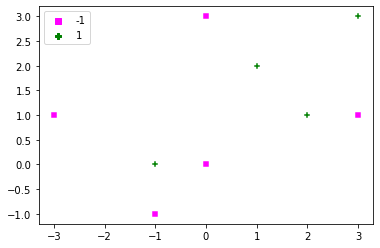

In [4]:
dat = np.array([[0, 3], [-1, 0], [1, 2], [2, 1], [3,3], [0, 0], [-1, -1], [-3, 1], [3, 1],[0,3]])
labels = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1,-1])


def plot_x(x, t, alpha=[], C=0):
    sns.scatterplot(dat[:,0], dat[:, 1], style=labels,
    hue=labels, markers=['s', 'P'],
    palette=['magenta', 'green'])
    if len(alpha) > 0:
        alpha_str = np.char.mod('%.1f', np.round(alpha, 1))
        ind_sv = np.where(alpha > ZERO)[0]
        for i in ind_sv:   
            plt.gca().text(dat[i,0], dat[i, 1]-.25, alpha_str[i] )

                  
plot_x(dat, labels)

In [117]:
dat.shape
x=np.dot(dat[5, :], dat[6, :])
x

0

In [3]:
# Objective function
def lagrange_dual(alpha, x, t):
    result = 0
    ind_sv = np.where(alpha > ZERO)[0]
    for i in ind_sv:
        for k in ind_sv:
            result = result + alpha[i]*alpha[k]*t[i]*t[k]*np.dot(x[i, :], x[k, :]) 
    result = 0.5*result - sum(alpha)     
    return result

In [4]:
dat = np.array([[0, 3], [-1, 0], [1, 2], [2, 1], [3,3], [0, 0], [-1, -1], [-3, 1], [3, 1],[0,3]])
labels = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1,-1])
m,n=dat.shape
C=10
alpha_0 = np.random.rand(m)*C
alpha_0

array([9.2085572 , 8.89818459, 8.49493264, 8.19122737, 5.04244649,
       2.21208295, 9.91626007, 0.99825693, 0.98481792, 6.15986331])

In [11]:
def alpha1_optimize(alpha_0,C):
    l=np.zeros([10,10])
    n=len(alpha_0)
    f=[]

    for index_i,i in enumerate(alpha_0):

        for index_k,k in enumerate(alpha_0):
            if index_i==index_k:
                continue
            else:

                K= np.dot(dat[index_i, :], dat[index_k, :])
                # print(K)
                result=0

                for index_i2,i2 in enumerate(alpha_0):

                    result  += alpha_0[index_i2]*labels[index_i2]*K
                    # print(result)
            
                alpha_0[index_k] = (1-labels[index_k]*(result))
                # print(alpha_0[index_k])
                if alpha_0[index_k] < 0:
                    alpha_0[index_k]=0
                if alpha_0[index_k] > C :
                    alpha_0[index_k] = C
                
                
                l[index_i,index_k]=alpha_0[index_k] 

    
    return(np.array(l))



In [12]:
def get_w(alpha, t, x):
    m = len(x)
    # Get all support vectors
    w = np.zeros(x.shape[1])
    for i in range(m):
        w = w + alpha[i]*t[i]*x[i, :]        
    return w

def get_w0(alpha, t, x, w, C):
    C_numeric = C-ZERO
    # Indices of support vectors with alpha<C
    ind_sv = np.where((alpha > ZERO)&(alpha < C_numeric))[0]
    w0 = 0.0
    for s in ind_sv:
        w0 = w0 + t[s] - np.dot(x[s, :], w)
    # Take the average    
    w0 = w0 / len(ind_sv)
    return w0

In [13]:
def classify_points(x_test, w, w0):
    # get y(x_test)
    predicted_labels = np.sum(x_test*w, axis=1) + w0
    predicted_labels = np.sign(predicted_labels)
    # Assign a label arbitrarily a +1 if it is zero
    predicted_labels[predicted_labels==0] = 1
    return predicted_labels

def misclassification_rate(labels, predictions):
    total = len(labels)
    errors = sum(labels != predictions)
    return errors/total*100

In [14]:
def plot_hyperplane(w, w0):
    x_coord = np.array(plt.gca().get_xlim())
    y_coord = -w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, y_coord, color='red')

def plot_margin(w, w0):
    x_coord = np.array(plt.gca().get_xlim())
    ypos_coord = 1/w[1] - w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, ypos_coord, '--', color='green') 
    yneg_coord = -1/w[1] - w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, yneg_coord, '--', color='magenta')

In [15]:
def display_SVM_result(x, t, C):
    # Get the alphas
    alpha = optimize_alpha(x, t, C)   
    # alpha=np.array([0.00000000e+00 ,2.06399894e-01 ,0.00000000e+00 ,0.00000000e+00,
  # 2.19035780e-01 ,1.00000000e-01, 4.83556177e-01, 5.69352863e-01,
  # 0.00000000e+00 ,0.00000000e+00])
    
    print(alpha)
    # Get the weights
    w = get_w(alpha, t, x)
    w0 = get_w0(alpha, t, x, w, C)
    print(w0)
    plot_x(x, t, alpha, C)
    xlim = plt.gca().get_xlim()
    
    ylim = plt.gca().get_ylim()
    plot_hyperplane(w, w0)
    plot_margin(w, w0)
    plt.xlim(xlim)
    plt.ylim(ylim)
    # Get the misclassification error and display it as title
    predictions = classify_points(x, w, w0)
    err = misclassification_rate(t, predictions)
    title = 'C = ' + str(C) + ',  Errors: ' + '{:.1f}'.format(err) + '%'
    title = title + ',  total SV = ' + str(len(alpha[alpha > ZERO]))
    plt.title(title)
    
display_SVM_result(dat, labels, 10)    
plt.show()

NameError: name 'optimize_alpha' is not defined

In [16]:
linear_constraint = LinearConstraint(labels, [0], [0])
print(linear_constraint)

In [17]:
bounds_alpha = Bounds(np.zeros(dat.shape[0]), np.full(dat.shape[0], 10))
print(bounds_alpha)

Bounds(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10]))


In [18]:
def optimize_alpha(x, t, C):
    m, n = x.shape
    np.random.seed(1)
    # Initialize alphas to random values
    alpha_0 = np.random.rand(m)*C
    # Define the constraint
    linear_constraint = LinearConstraint(t, [0], [0])
    # Define the bounds
    bounds_alpha = Bounds(np.zeros(m), np.full(m, C))
    # Find the optimal value of alpha
    result = minimize(lagrange_dual, alpha_0, args = (x, t),
                      hess=BFGS(), constraints=[linear_constraint],
                      bounds=bounds_alpha)
    # The optimized value of alpha lies in result.x
    alpha = result.x
    return alpha

In [29]:
def get_w(alpha, t, x):
    m = len(x)
    # Get all support vectors
    w = np.zeros(x.shape[1])
    for i in range(m):
        w = w + alpha[i]*t[i]*x[i, :]        
    return w

def get_w0(alpha, t, x, w, C):
    C_numeric = C-ZERO
    print(C_numeric,ZERO)
    # Indices of support vectors with alpha<C
    print(alpha)
    ind_sv = np.where((alpha > ZERO)&(alpha < C_numeric))[0]
    w0 = 0.0
    print(ind_sv)
    for s in ind_sv:
        w0 = w0 + t[s] - np.dot(x[s, :], w)
    # Take the average    
    w0 = w0 / len(ind_sv)
    return w0

In [20]:
def classify_points(x_test, w, w0):
    # get y(x_test)
    predicted_labels = np.sum(x_test*w, axis=1) + w0
    predicted_labels = np.sign(predicted_labels)
    # # Assign a label arbitrarily a +1 if it is zero
    # predicted_labels[predicted_labels==0] = 1
    return predicted_labels

def misclassification_rate(labels, predictions):
    total = len(labels)
    errors = sum(labels != predictions)
    return errors/total*100

In [21]:
def plot_hyperplane(w, w0):
    x_coord = np.array(plt.gca().get_xlim())
    y_coord = -w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, y_coord, color='red')

def plot_margin(w, w0):
    x_coord = np.array(plt.gca().get_xlim())
    ypos_coord = 1/w[1] - w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, ypos_coord, '--', color='green') 
    yneg_coord = -1/w[1] - w0/w[1] - w[0]/w[1] * x_coord
    plt.plot(x_coord, yneg_coord, '--', color='magenta')

In [30]:
def display_SVM_result(x, t, C):
    # Get the alphas
    alpha = optimize_alpha(x, t, C)   
    # Get the weights
    w = get_w(alpha, t, x)
    w0 = get_w0(alpha, t, x, w, C)
  
    print(alpha)
    plot_x(x, t, alpha, C)
    xlim = plt.gca().get_xlim()
    
    ylim = plt.gca().get_ylim()
    plot_hyperplane(w, w0)
    plot_margin(w, w0)
    plt.xlim(xlim)
    plt.ylim(ylim)
    # Get the misclassification error and display it as title
    predictions = classify_points(x, w, w0)
    print(predictions)
    err = misclassification_rate(t, predictions)
    title = 'C = ' + str(C) + ',  Errors: ' + '{:.1f}'.format(err) + '%'
    title = title + ',  total SV = ' + str(len(alpha[alpha > ZERO]))
    plt.title(title)
    
display_SVM_result(dat, labels, 10)    
plt.show()

9.9999999 1e-07
[5.96439997e+00 1.00000000e+01 8.19016030e+00 1.00000000e+01
 3.34632500e-07 1.00000000e+01 1.59073623e-01 3.99548698e+00
 1.00000000e+01 1.00000000e+01]
[0 2 4 6 7]
[5.96439997e+00 1.00000000e+01 8.19016030e+00 1.00000000e+01
 3.34632500e-07 1.00000000e+01 1.59073623e-01 3.99548698e+00
 1.00000000e+01 1.00000000e+01]


NameError: name 'plot_x' is not defined

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


array([[ 0.62835793,  4.4601363 ],
       [ 0.89011768,  1.79849015],
       [ 3.19466821, -0.33716216],
       [ 3.2460247 ,  2.84942165],
       [ 2.50904929,  5.7731461 ],
       [ 1.74371499,  0.953829  ],
       [-0.07228289,  2.88376939],
       [ 1.54561534,  0.45958936],
       [ 0.58894326,  4.00148458],
       [ 1.28933778,  3.44969159],
       [ 1.42013331,  4.63746165],
       [ 2.47034915,  4.09862906],
       [ 1.84070628,  3.56162231],
       [ 1.24212124, -0.82861894],
       [ 1.54446238, -0.28296852],
       [ 2.78435808,  1.02664657],
       [ 2.84382807,  3.32650945],
       [ 2.52092996, -0.63858003],
       [ 1.9263585 ,  4.15243012],
       [-0.73000011,  6.25456272],
       [ 1.15980096,  1.28456616],
       [ 2.45760916,  0.21285357],
       [ 0.80247216,  1.67515402],
       [ 2.20656076,  5.50616718],
       [ 2.23269366,  0.49588272],
       [ 1.42094543,  0.53492249],
       [ 2.02708529,  1.32599553],
       [ 0.42506917,  1.36044592],
       [ 0.44136967,

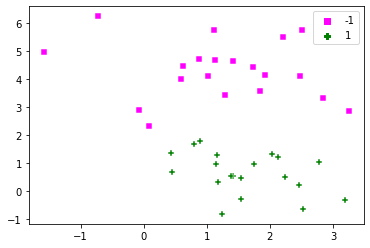

In [146]:
dat, labels = dt.make_blobs(n_samples=[20,20],
                           cluster_std=1,
                           random_state=0)
labels[labels==0] = -1
plot_x(dat, labels)
dat

In [1]:
fig = plt.figure(figsize=(8,25))

i=0
C_array = [1e-2, 100, 1e5]

for C in C_array:
    fig.add_subplot(311+i)    
    display_SVM_result(dat, labels, C)  
    i = i + 1

NameError: name 'plt' is not defined